# 🏏 Bangla Sports Sentiment Analysis
## Model: Multinomial Naive Bayes (MNB) | Word + Char N-gram TF-IDF
## 3 Data Splits: 70:30 | 80:20 | 90:10 with Hyperparameter Tuning
---

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 📦 Step 1: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns
import re, os, warnings
warnings.filterwarnings('ignore')
os.makedirs('results', exist_ok=True)

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack

print('✅ সব Library import সফল!')

✅ সব Library import সফল!


## 📂 Step 2: Dataset Load

In [4]:
df = pd.read_excel('/content/drive/MyDrive/dataset/Bangla_Sports_Sentiment_Analysis_Dataset.xlsx')
print('📊 Raw Dataset Shape:', df.shape)
print('\n📋 Columns:', df.columns.tolist())
print('\n📊 Raw Category Distribution:')
print(df['Category'].value_counts())
df.head()

📊 Raw Dataset Shape: (82611, 3)

📋 Columns: ['Comment ', 'Category', 'Cleaned_Text']

📊 Raw Category Distribution:
Category
Negative    41355
Positive    41256
Name: count, dtype: int64


,Comment,Category,Cleaned_Text
0,মনে হয় পাড়া-মহল্লার খেলা দেখছি।,Positive,মন হয় পাড়া মহল্ল খেলা দেখ
1,বাংলাদেশের ফুটবল না খেলে কুত কুত খেললেই পারে,Positive,বাংলাদেশ ফুটবল খালা কুত কুত খেললে
2,বাংলাদেশের দামরা ছেলে গুলো কি খেলছে,Positive,বাংলাদেশ দাম ছালা খেল
3,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতেই পারেনা,Positive,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতে পারেনা
4,"খারাপ লাগে তখন যখন,,,একজন বল বাস করে গোলের দিক...",Positive,খারাপ লাগ যখন একজন বল বাস গোল ছোর প্লেয় সামন য...


## 🧹 Step 3: Data Cleaning & Preprocessing
### তিনটা সমস্যা পাওয়া গেছে Dataset এ:
- **~34,663 Duplicate texts**
- **~1,751 Conflicting labels** (same text → different label)
- **Noise**: URLs, English chars, special symbols

In [5]:
print('=== Data Quality Check ===')
print(f'Total rows       : {len(df):,}')
print(f'Missing Comment  : {df["Comment "].isna().sum()}')
print(f'Missing Category : {df["Category"].isna().sum()}')
print(f'Duplicate Comment: {df["Comment "].duplicated().sum():,}')

=== Data Quality Check ===
Total rows       : 82,611
Missing Comment  : 5
Missing Category : 0
Duplicate Comment: 34,663


In [6]:
def clean_bangla(text):
    """Bangla text cleaner — শুধু Bangla Unicode রাখা হয়"""
    if pd.isna(text): return ''
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)       # URLs
    text = re.sub(r'[^\u0980-\u09FF\s]', ' ', text)  # Non-Bangla
    return re.sub(r'\s+', ' ', text).strip()

df['clean'] = df['Comment '].apply(clean_bangla)
df = df[df['clean'].str.len() > 3].reset_index(drop=True)

# Majority vote — conflicting label হলে সবচেয়ে বেশি label রাখা হয়
df_clean = df.groupby('clean')['Category'].agg(
    lambda x: x.value_counts().idxmax()
).reset_index()
df_clean.columns = ['text', 'label']

print(f'Raw          : {len(df):,} rows')
print(f'After cleanup: {len(df_clean):,} rows')
print(f'\nFinal Category Distribution:')
print(df_clean['label'].value_counts())
print(f'\nBalance: {df_clean["label"].value_counts(normalize=True).mul(100).round(1).to_dict()}')

Raw          : 82,047 rows
After cleanup: 46,325 rows

Final Category Distribution:
label
Positive    25774
Negative    20551
Name: count, dtype: int64

Balance: {'Positive': 55.6, 'Negative': 44.4}


## 📊 Step 4: EDA — Exploratory Data Analysis

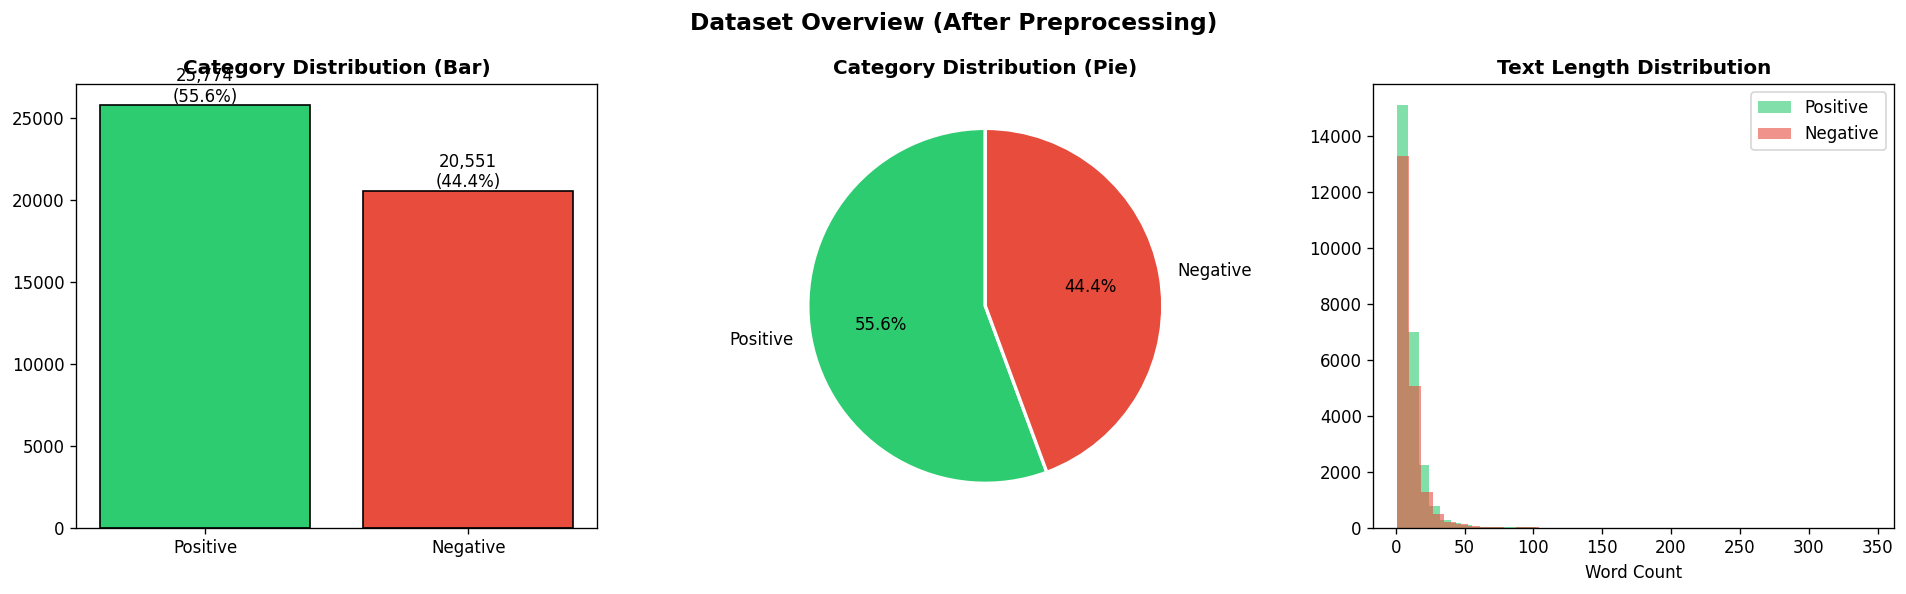

✅ Saved!


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dataset Overview (After Preprocessing)', fontsize=14, fontweight='bold')
cat_counts = df_clean['label'].value_counts()
colors_main = ['#2ecc71', '#e74c3c']

bars = axes[0].bar(cat_counts.index, cat_counts.values, color=colors_main, edgecolor='black')
axes[0].set_title('Category Distribution (Bar)', fontweight='bold')
for i, (bar, v) in enumerate(zip(bars, cat_counts.values)):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+200, f'{v:,}\n({v/len(df_clean)*100:.1f}%)', ha='center')

axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=colors_main, startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Category Distribution (Pie)', fontweight='bold')

df_clean['text_len'] = df_clean['text'].apply(lambda x: len(x.split()))
axes[2].hist(df_clean[df_clean['label']=='Positive']['text_len'], bins=40, alpha=0.6, color='#2ecc71', label='Positive')
axes[2].hist(df_clean[df_clean['label']=='Negative']['text_len'], bins=40, alpha=0.6, color='#e74c3c', label='Negative')
axes[2].set_title('Text Length Distribution', fontweight='bold')
axes[2].set_xlabel('Word Count'); axes[2].legend()

plt.tight_layout()
plt.savefig('results/01_dataset_overview.png', bbox_inches='tight')
plt.show()
print('✅ Saved!')

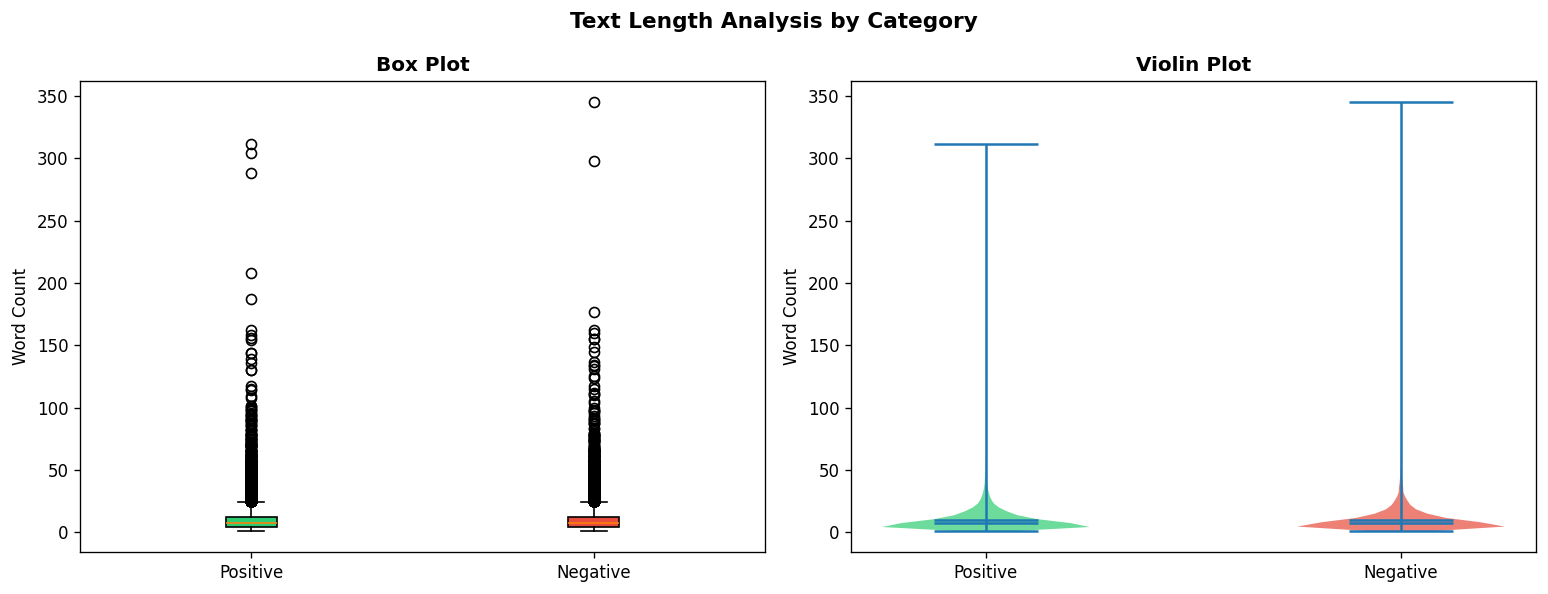

✅ Saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Text Length Analysis by Category', fontsize=13, fontweight='bold')

pos_len = df_clean[df_clean['label']=='Positive']['text_len'].values
neg_len = df_clean[df_clean['label']=='Negative']['text_len'].values

bp = axes[0].boxplot([pos_len, neg_len], labels=['Positive','Negative'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71'); bp['boxes'][1].set_facecolor('#e74c3c')
axes[0].set_title('Box Plot', fontweight='bold'); axes[0].set_ylabel('Word Count')

vp = axes[1].violinplot([pos_len, neg_len], positions=[1,2], showmeans=True, showmedians=True)
for i, pc in enumerate(vp['bodies']): pc.set_facecolor(['#2ecc71','#e74c3c'][i]); pc.set_alpha(0.7)
axes[1].set_xticks([1,2]); axes[1].set_xticklabels(['Positive','Negative'])
axes[1].set_title('Violin Plot', fontweight='bold'); axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('results/02_boxplot_violin.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 🔤 Step 5: Feature Extraction Setup

In [9]:
le = LabelEncoder()
y = le.fit_transform(df_clean['label'])  # Negative=0, Positive=1
X = df_clean['text'].values
print(f'✅ X size: {len(X):,}  |  Label: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print(f'Negative: {np.sum(y==0):,}  Positive: {np.sum(y==1):,}')

✅ X size: 46,325  |  Label: {'Negative': np.int64(0), 'Positive': np.int64(1)}
Negative: 20,551  Positive: 25,774


## 🔧 Step 6: Hyperparameter Tuning on 80:20 Split

In [10]:
print('🔧 GridSearchCV Hyperparameter Tuning — 80:20 split...\n')

X_tr80, X_te80, y_tr80, y_te80 = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='word', sublinear_tf=True)),
    ('mnb',   MultinomialNB())
])

param_grid = {
    'tfidf__ngram_range'  : [(1,1), (1,2), (1,3)],
    'tfidf__max_features' : [30000, 50000, 80000],
    'tfidf__min_df'       : [1, 2],
    'tfidf__max_df'       : [0.90, 0.95],
    'mnb__alpha'          : [0.01, 0.05, 0.1, 0.5, 1.0]
}

gs = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
gs.fit(X_tr80, y_tr80)

best_params   = gs.best_params_
best_cv_score = gs.best_score_

print('\n' + '='*55)
print('✅ Tuning সম্পন্ন!')
print(f'Best CV Accuracy: {best_cv_score*100:.2f}%')
print('Best Params:')
for k,v in best_params.items(): print(f'  {k}: {v}')

🔧 GridSearchCV Hyperparameter Tuning — 80:20 split...

Fitting 5 folds for each of 180 candidates, totalling 900 fits

✅ Tuning সম্পন্ন!
Best CV Accuracy: 64.69%
Best Params:
  mnb__alpha: 1.0
  tfidf__max_df: 0.9
  tfidf__max_features: 30000
  tfidf__min_df: 2
  tfidf__ngram_range: (1, 3)


## 🚀 Step 7: তিনটা Split এ Training & Evaluation

In [11]:
best_ngram    = best_params['tfidf__ngram_range']
best_max_feat = best_params['tfidf__max_features']
best_min_df   = best_params['tfidf__min_df']
best_max_df   = best_params['tfidf__max_df']
best_alpha    = best_params['mnb__alpha']

splits      = [('70:30', 0.30), ('80:20', 0.20), ('90:10', 0.10)]
colors_roc  = ['#3498db', '#e74c3c', '#2ecc71']
all_results = {}

print('🚀 Training শুরু...\n' + '='*65)

for sname, tsize in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=tsize, random_state=42, stratify=y
    )

    # Word TF-IDF
    tfw = TfidfVectorizer(analyzer='word', ngram_range=best_ngram,
                          max_features=best_max_feat, min_df=best_min_df,
                          max_df=best_max_df, sublinear_tf=True)
    # Character TF-IDF — Bangla morphology এর জন্য
    tfc = TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4),
                          max_features=best_max_feat, sublinear_tf=True)

    Xtr_w = tfw.fit_transform(X_train); Xte_w = tfw.transform(X_test)
    Xtr_c = tfc.fit_transform(X_train); Xte_c = tfc.transform(X_test)

    X_tr_f = hstack([Xtr_w, Xtr_c])
    X_te_f = hstack([Xte_w, Xte_c])

    model = MultinomialNB(alpha=best_alpha)
    model.fit(X_tr_f, y_train)

    y_pred = model.predict(X_te_f)
    y_prob = model.predict_proba(X_te_f)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    pc_c, rc_c, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rc_c, pc_c)

    all_results[sname] = dict(
        accuracy=acc, precision=prec, recall=rec, f1=f1,
        cm=cm, fpr=fpr, tpr=tpr, roc_auc=roc_auc,
        pc=pc_c, rc=rc_c, pr_auc=pr_auc,
        model=model, tfw=tfw, tfc=tfc,
        X_tr_f=X_tr_f, X_te_f=X_te_f, y_train=y_train, y_test=y_test,
        train_size=len(X_train), test_size_n=len(X_test)
    )

    print(f'\n📊 Split {sname}')
    print(f'   Train: {len(X_train):,} | Test: {len(X_test):,}')
    print(f'   Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    print(f'   Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')
    print(f'   ROC-AUC  : {roc_auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Negative','Positive'], digits=4))

split_names = list(all_results.keys())
print('\n✅ তিনটা Split সম্পন্ন!')

🚀 Training শুরু...

📊 Split 70:30
   Train: 32,427 | Test: 13,898
   Accuracy : 0.7134 (71.34%)
   Precision: 0.7338 | Recall: 0.7610 | F1: 0.7471
   ROC-AUC  : 0.7837
              precision    recall  f1-score   support

    Negative     0.6857    0.6537    0.6693      6166
    Positive     0.7338    0.7610    0.7471      7732

    accuracy                         0.7134     13898
   macro avg     0.7097    0.7074    0.7082     13898
weighted avg     0.7124    0.7134    0.7126     13898


📊 Split 80:20
   Train: 37,060 | Test: 9,265
   Accuracy : 0.7142 (71.42%)
   Precision: 0.7362 | Recall: 0.7579 | F1: 0.7469
   ROC-AUC  : 0.7843
              precision    recall  f1-score   support

    Negative     0.6847    0.6594    0.6718      4110
    Positive     0.7362    0.7579    0.7469      5155

    accuracy                         0.7142      9265
   macro avg     0.7104    0.7086    0.7093      9265
weighted avg     0.7133    0.7142    0.7136      9265


📊 Split 90:10
   Train: 41,69

## 📈 Step 8: Confusion Matrix

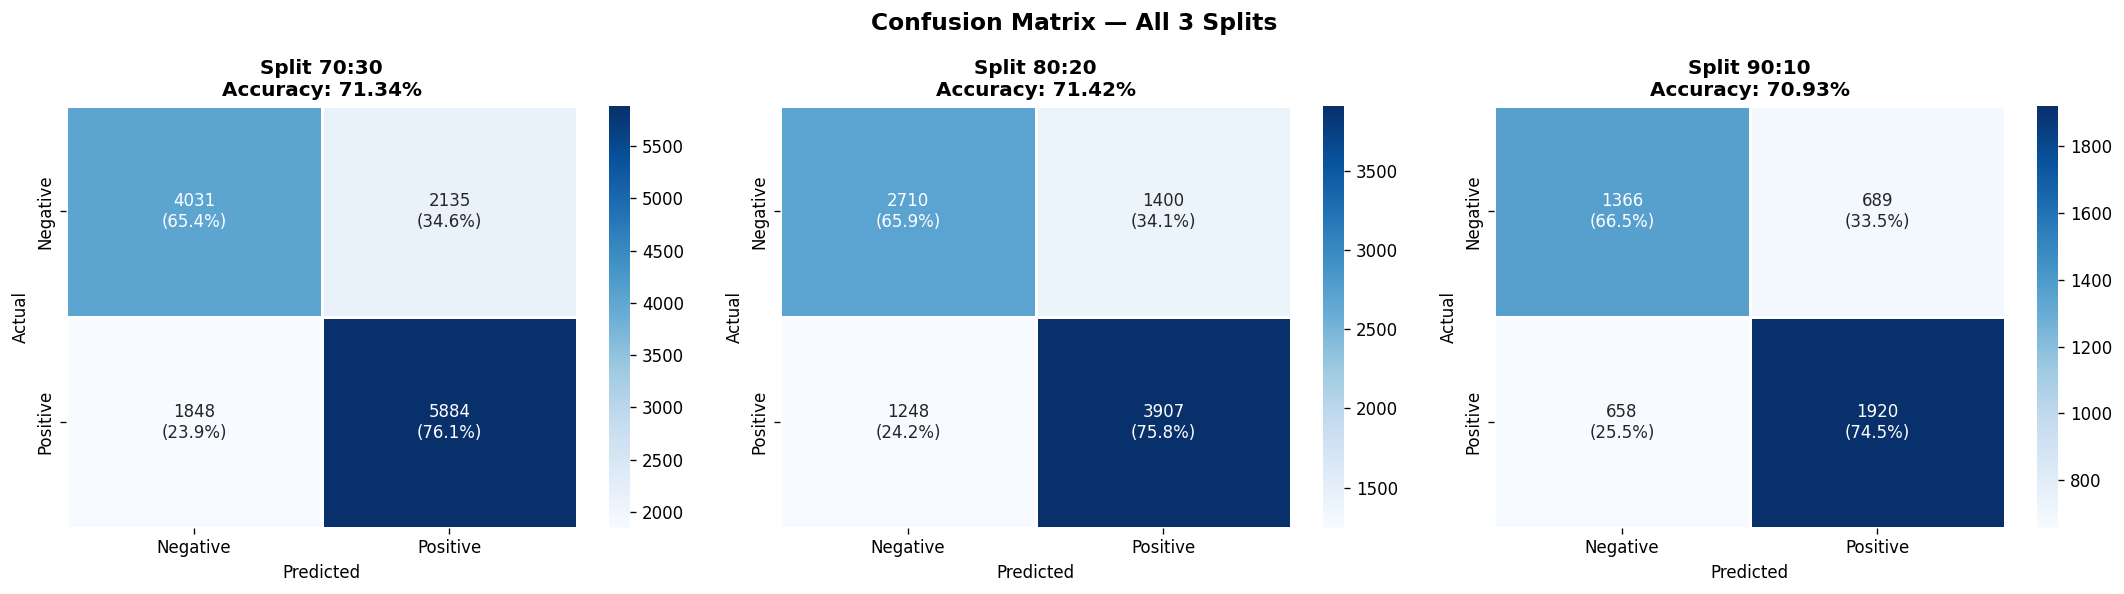

✅ Saved!


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix — All 3 Splits', fontsize=14, fontweight='bold')
for i, (sname, res) in enumerate(all_results.items()):
    cm = res['cm']
    cm_p = cm.astype('float') / cm.sum(axis=1)[:,np.newaxis] * 100
    ann = np.array([[f'{cm[r,c]}\n({cm_p[r,c]:.1f}%)' for c in range(2)] for r in range(2)])
    sns.heatmap(cm, annot=ann, fmt='', ax=axes[i], cmap='Blues', linewidths=1.5,
                xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
    axes[i].set_title(f'Split {sname}\nAccuracy: {res["accuracy"]*100:.2f}%', fontweight='bold')
    axes[i].set_ylabel('Actual'); axes[i].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('results/03_confusion_matrix.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 📉 Step 9: ROC Curve

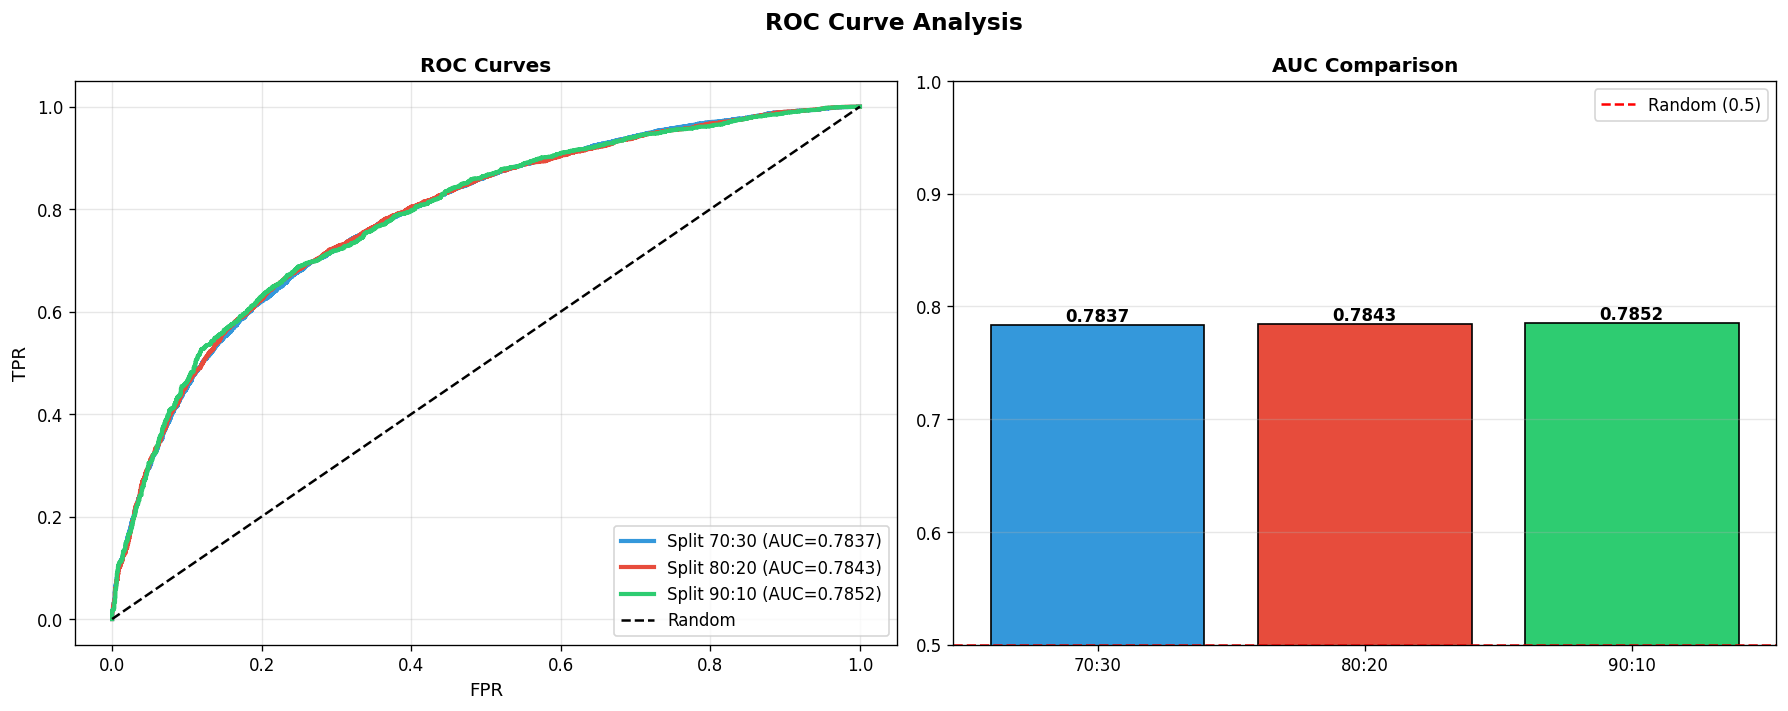

✅ Saved!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ROC Curve Analysis', fontsize=14, fontweight='bold')
for i, (sname, res) in enumerate(all_results.items()):
    axes[0].plot(res['fpr'], res['tpr'], color=colors_roc[i], lw=2.5,
                 label=f'Split {sname} (AUC={res["roc_auc"]:.4f})')
axes[0].plot([0,1],[0,1],'k--',lw=1.5,label='Random')
axes[0].set_xlabel('FPR',fontsize=11); axes[0].set_ylabel('TPR',fontsize=11)
axes[0].set_title('ROC Curves', fontweight='bold'); axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

auc_v = [all_results[s]['roc_auc'] for s in split_names]
bars = axes[1].bar(split_names, auc_v, color=colors_roc, edgecolor='black')
axes[1].set_ylim([0.5,1.0])
axes[1].axhline(y=0.5,color='red',linestyle='--',lw=1.5,label='Random (0.5)')
for bar,v in zip(bars,auc_v): axes[1].text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].set_title('AUC Comparison',fontweight='bold'); axes[1].legend(); axes[1].grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig('results/04_roc_curve.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 📊 Step 10: Precision-Recall Curve

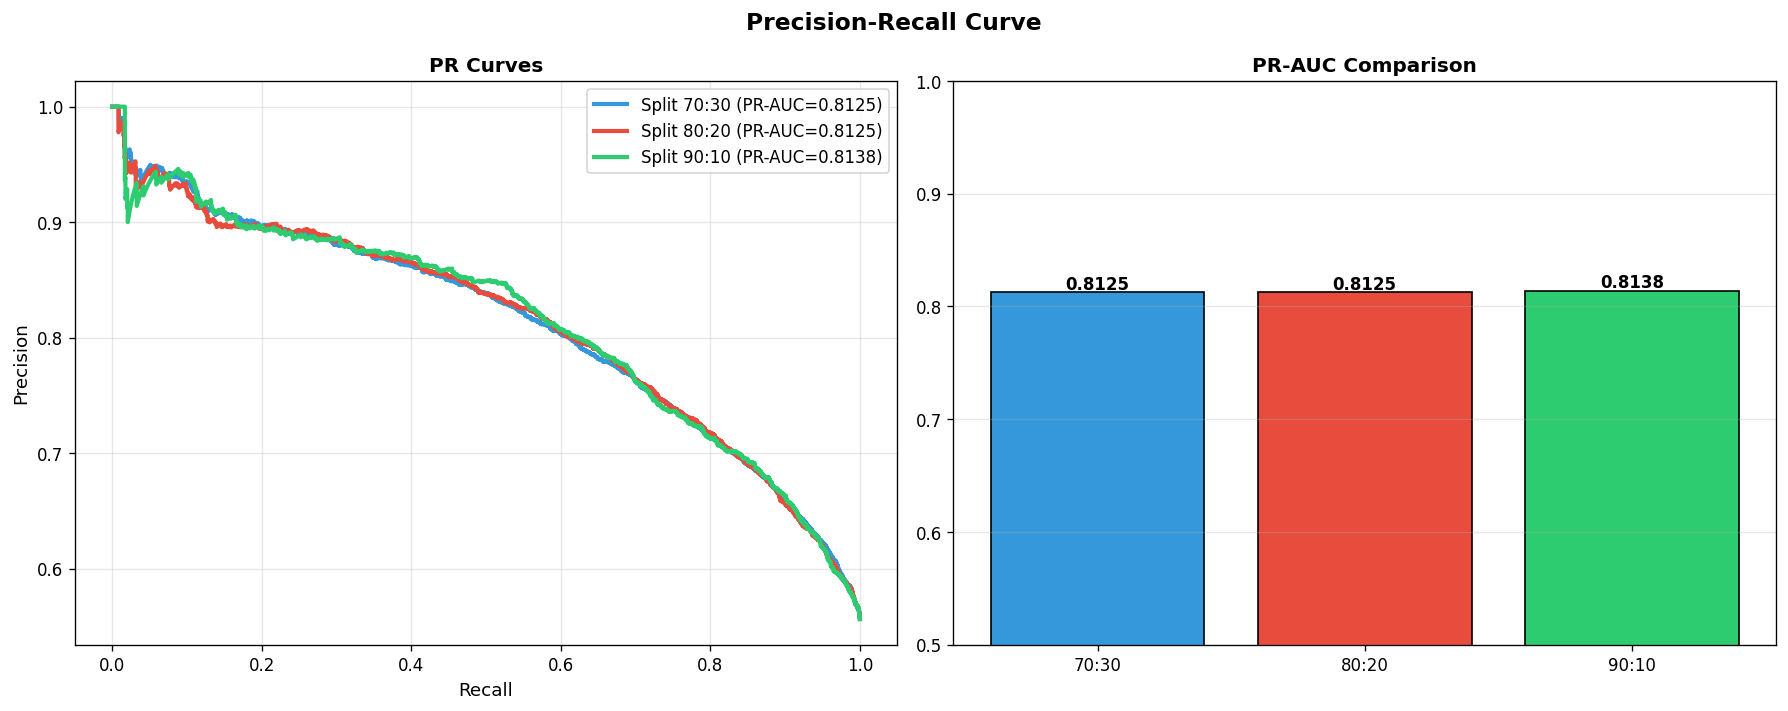

✅ Saved!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Precision-Recall Curve', fontsize=14, fontweight='bold')
for i, (sname, res) in enumerate(all_results.items()):
    axes[0].plot(res['rc'], res['pc'], color=colors_roc[i], lw=2.5,
                 label=f'Split {sname} (PR-AUC={res["pr_auc"]:.4f})')
axes[0].set_xlabel('Recall',fontsize=11); axes[0].set_ylabel('Precision',fontsize=11)
axes[0].set_title('PR Curves',fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

pr_v = [all_results[s]['pr_auc'] for s in split_names]
bars = axes[1].bar(split_names, pr_v, color=colors_roc, edgecolor='black')
axes[1].set_ylim([0.5,1.0])
for bar,v in zip(bars,pr_v): axes[1].text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].set_title('PR-AUC Comparison',fontweight='bold'); axes[1].grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig('results/05_pr_curve.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 📉 Step 11: Learning Curves

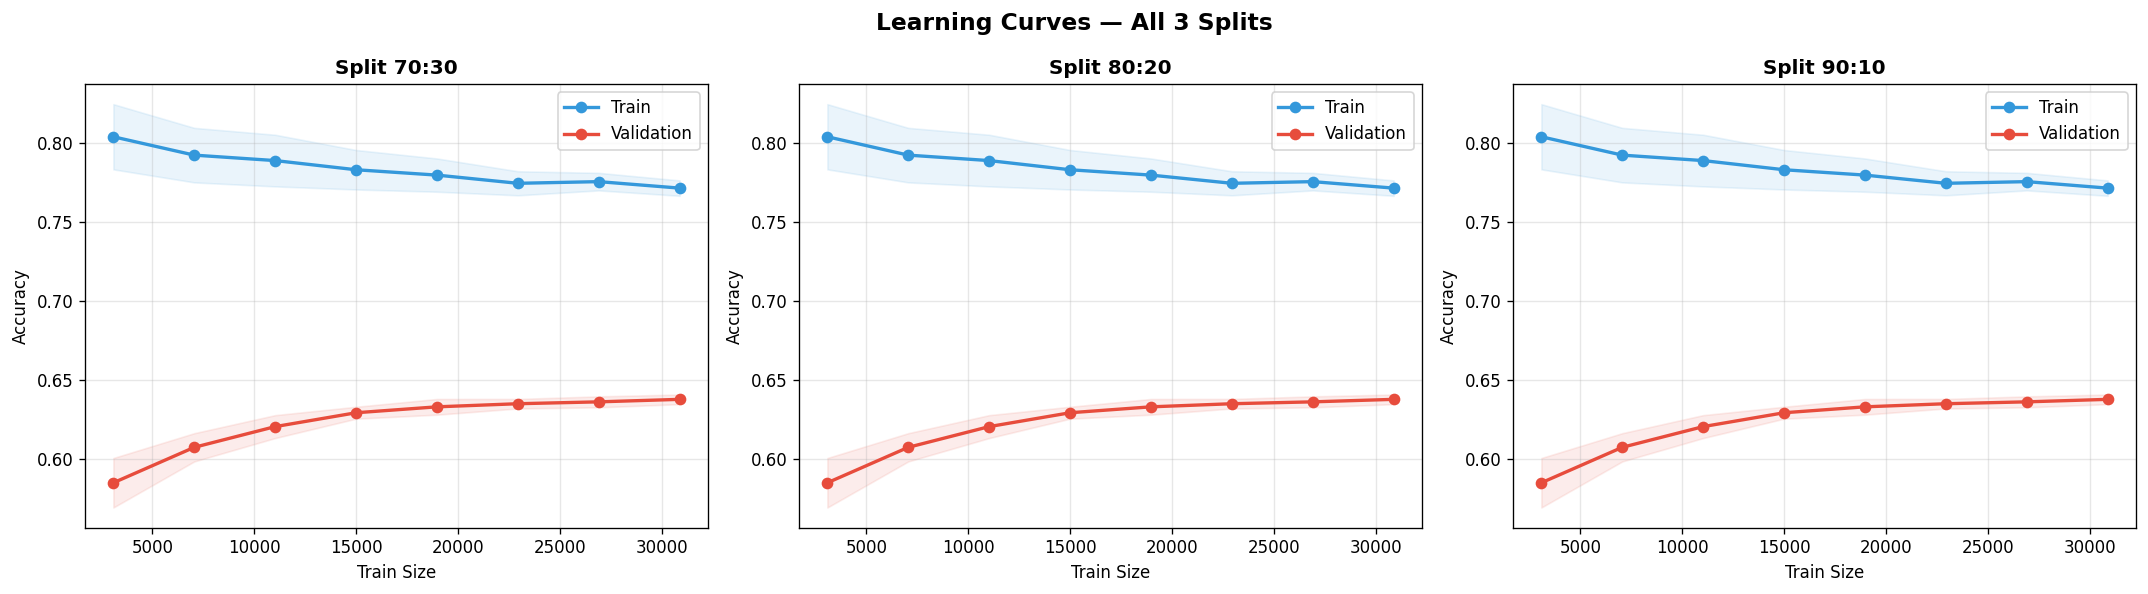

✅ Saved!


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Learning Curves — All 3 Splits', fontsize=14, fontweight='bold')
for i, (sname, _) in enumerate(all_results.items()):
    lc_pipe = Pipeline([('tfidf', TfidfVectorizer(analyzer='word', ngram_range=best_ngram,
        max_features=best_max_feat, min_df=best_min_df, max_df=best_max_df, sublinear_tf=True)),
        ('mnb', MultinomialNB(alpha=best_alpha))])
    ts, trs, vs = learning_curve(lc_pipe, X, y,
        train_sizes=np.linspace(0.1,1.0,8), cv=3, scoring='accuracy', n_jobs=-1)
    trm=trs.mean(1); vm=vs.mean(1)
    axes[i].plot(ts, trm,'o-',color='#3498db',label='Train',lw=2)
    axes[i].fill_between(ts, trm-trs.std(1), trm+trs.std(1), alpha=0.1, color='#3498db')
    axes[i].plot(ts, vm,'o-',color='#e74c3c',label='Validation',lw=2)
    axes[i].fill_between(ts, vm-vs.std(1), vm+vs.std(1), alpha=0.1, color='#e74c3c')
    axes[i].set_title(f'Split {sname}',fontweight='bold')
    axes[i].set_xlabel('Train Size'); axes[i].set_ylabel('Accuracy')
    axes[i].legend(); axes[i].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('results/06_learning_curves.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 📊 Step 12: Metrics Comparison Bar Charts

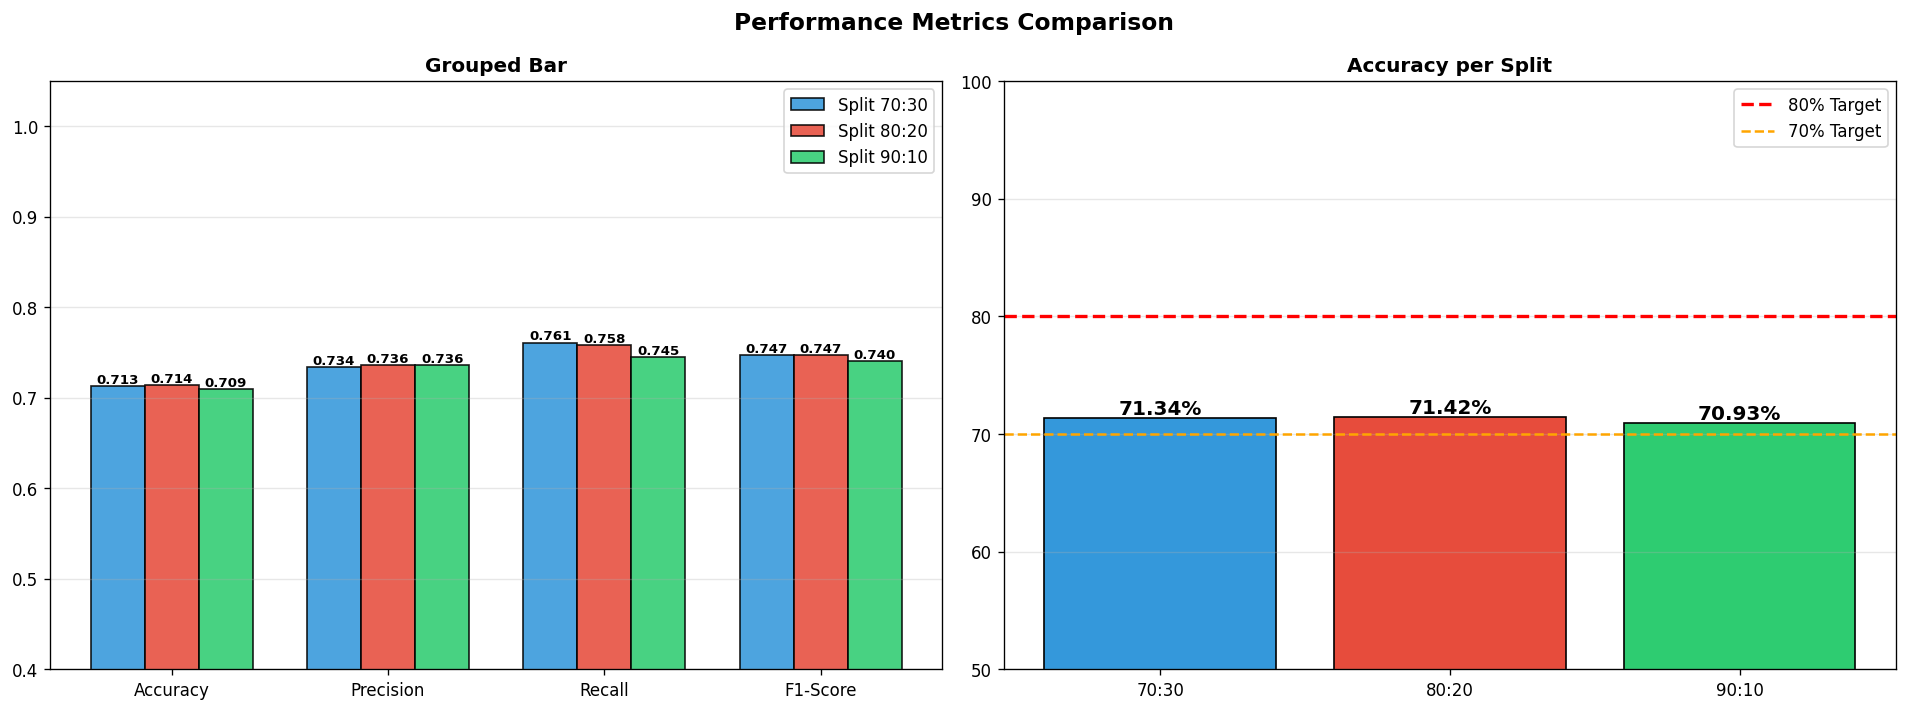

✅ Saved!


In [16]:
metrics=['accuracy','precision','recall','f1']; mlbls=['Accuracy','Precision','Recall','F1-Score']
x=np.arange(len(metrics)); w=0.25
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Performance Metrics Comparison', fontsize=14, fontweight='bold')
for i,(sname,res) in enumerate(all_results.items()):
    vals=[res[m] for m in metrics]
    bars=axes[0].bar(x+i*w, vals, w, label=f'Split {sname}', color=colors_roc[i], edgecolor='black', alpha=0.88)
    for bar,v in zip(bars,vals): axes[0].text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_xticks(x+w); axes[0].set_xticklabels(mlbls); axes[0].set_ylim([0.4,1.05])
axes[0].set_title('Grouped Bar',fontweight='bold'); axes[0].legend(); axes[0].grid(axis='y',alpha=0.3)

acc_p=[all_results[s]['accuracy']*100 for s in split_names]
bars2=axes[1].bar(split_names, acc_p, color=colors_roc, edgecolor='black')
axes[1].axhline(y=80,color='red',linestyle='--',lw=2,label='80% Target')
axes[1].axhline(y=70,color='orange',linestyle='--',lw=1.5,label='70% Target')
for bar,v in zip(bars2,acc_p): axes[1].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylim([50,100]); axes[1].set_title('Accuracy per Split',fontweight='bold'); axes[1].legend(); axes[1].grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig('results/07_metrics_comparison.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 🔥 Step 13: Feature Importance

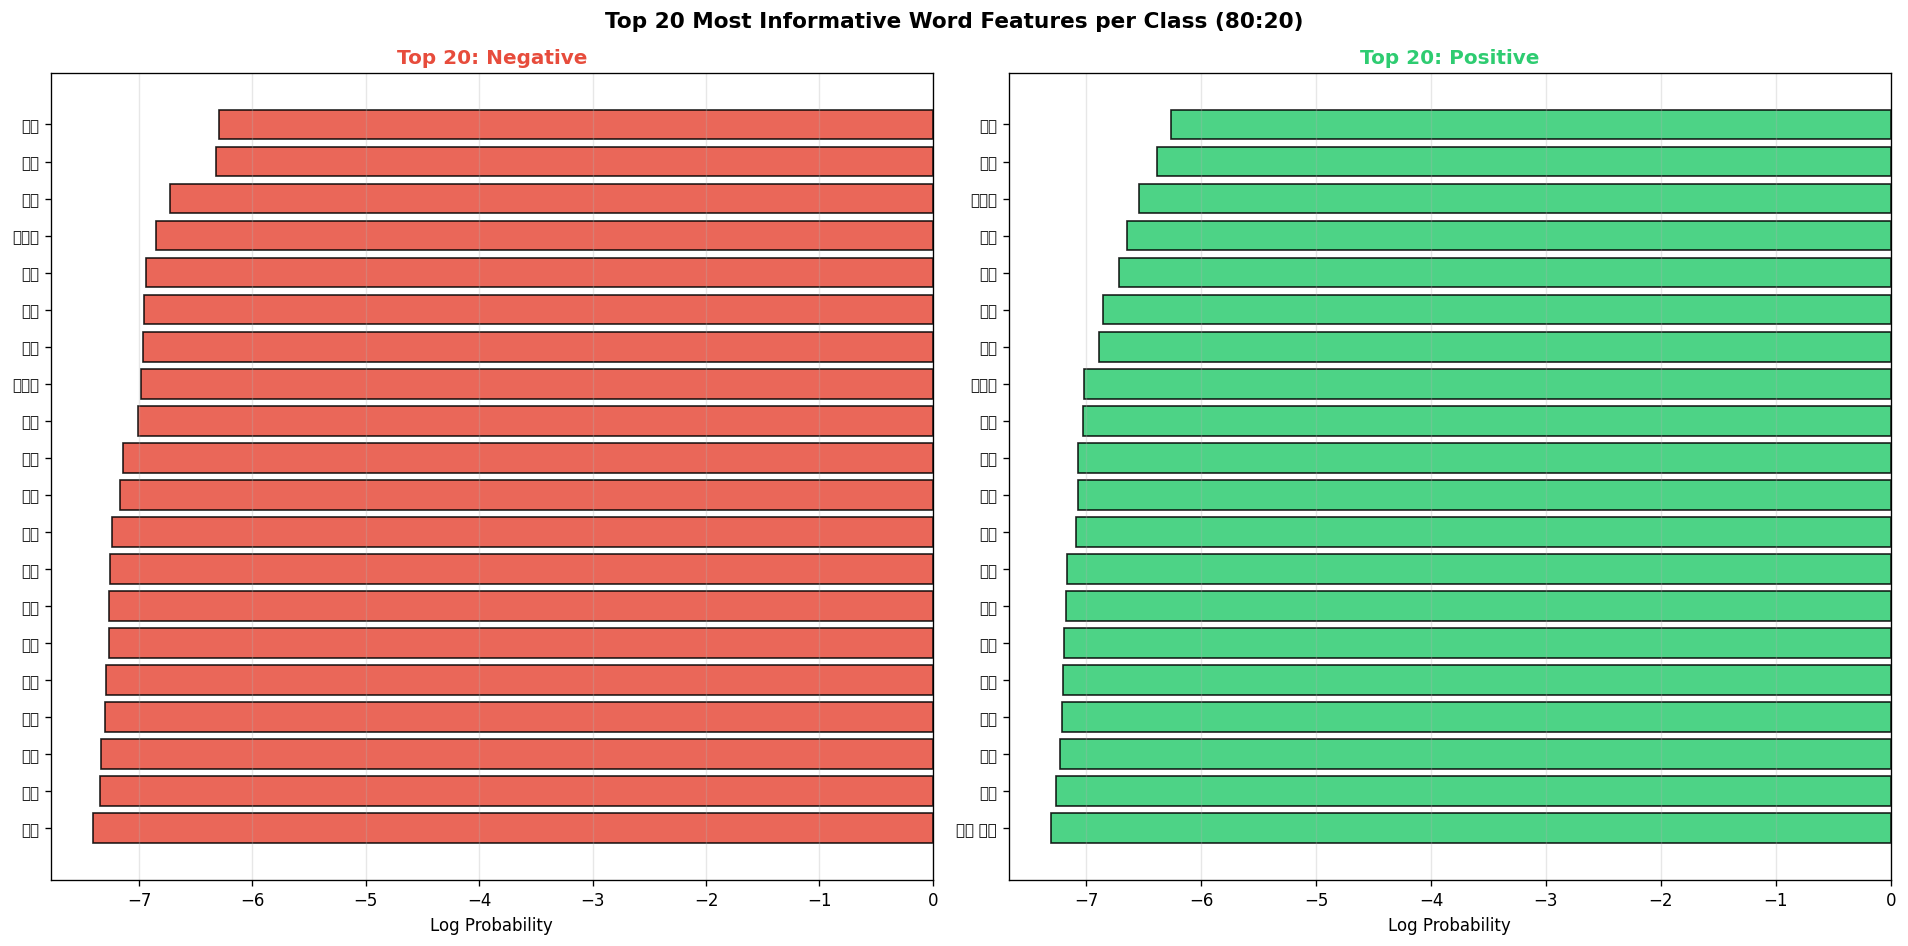

✅ Saved!


In [17]:
model_80 = all_results['80:20']['model']
tfw_80   = all_results['80:20']['tfw']
fn_w     = np.array(tfw_80.get_feature_names_out())

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Top 20 Most Informative Word Features per Class (80:20)', fontsize=13, fontweight='bold')
for ci,(cls,clr) in enumerate(zip(['Negative','Positive'],['#e74c3c','#2ecc71'])):
    lp = model_80.feature_log_prob_[ci][:len(fn_w)]
    top20 = np.argsort(lp)[-20:][::-1]
    axes[ci].barh(range(20), lp[top20][::-1], color=clr, edgecolor='black', alpha=0.85)
    axes[ci].set_yticks(range(20)); axes[ci].set_yticklabels(fn_w[top20][::-1], fontsize=9)
    axes[ci].set_title(f'Top 20: {cls}', fontweight='bold', color=clr)
    axes[ci].set_xlabel('Log Probability'); axes[ci].grid(axis='x',alpha=0.3)
plt.tight_layout(); plt.savefig('results/08_feature_importance.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 🗺️ Step 14: Correlation Heatmap

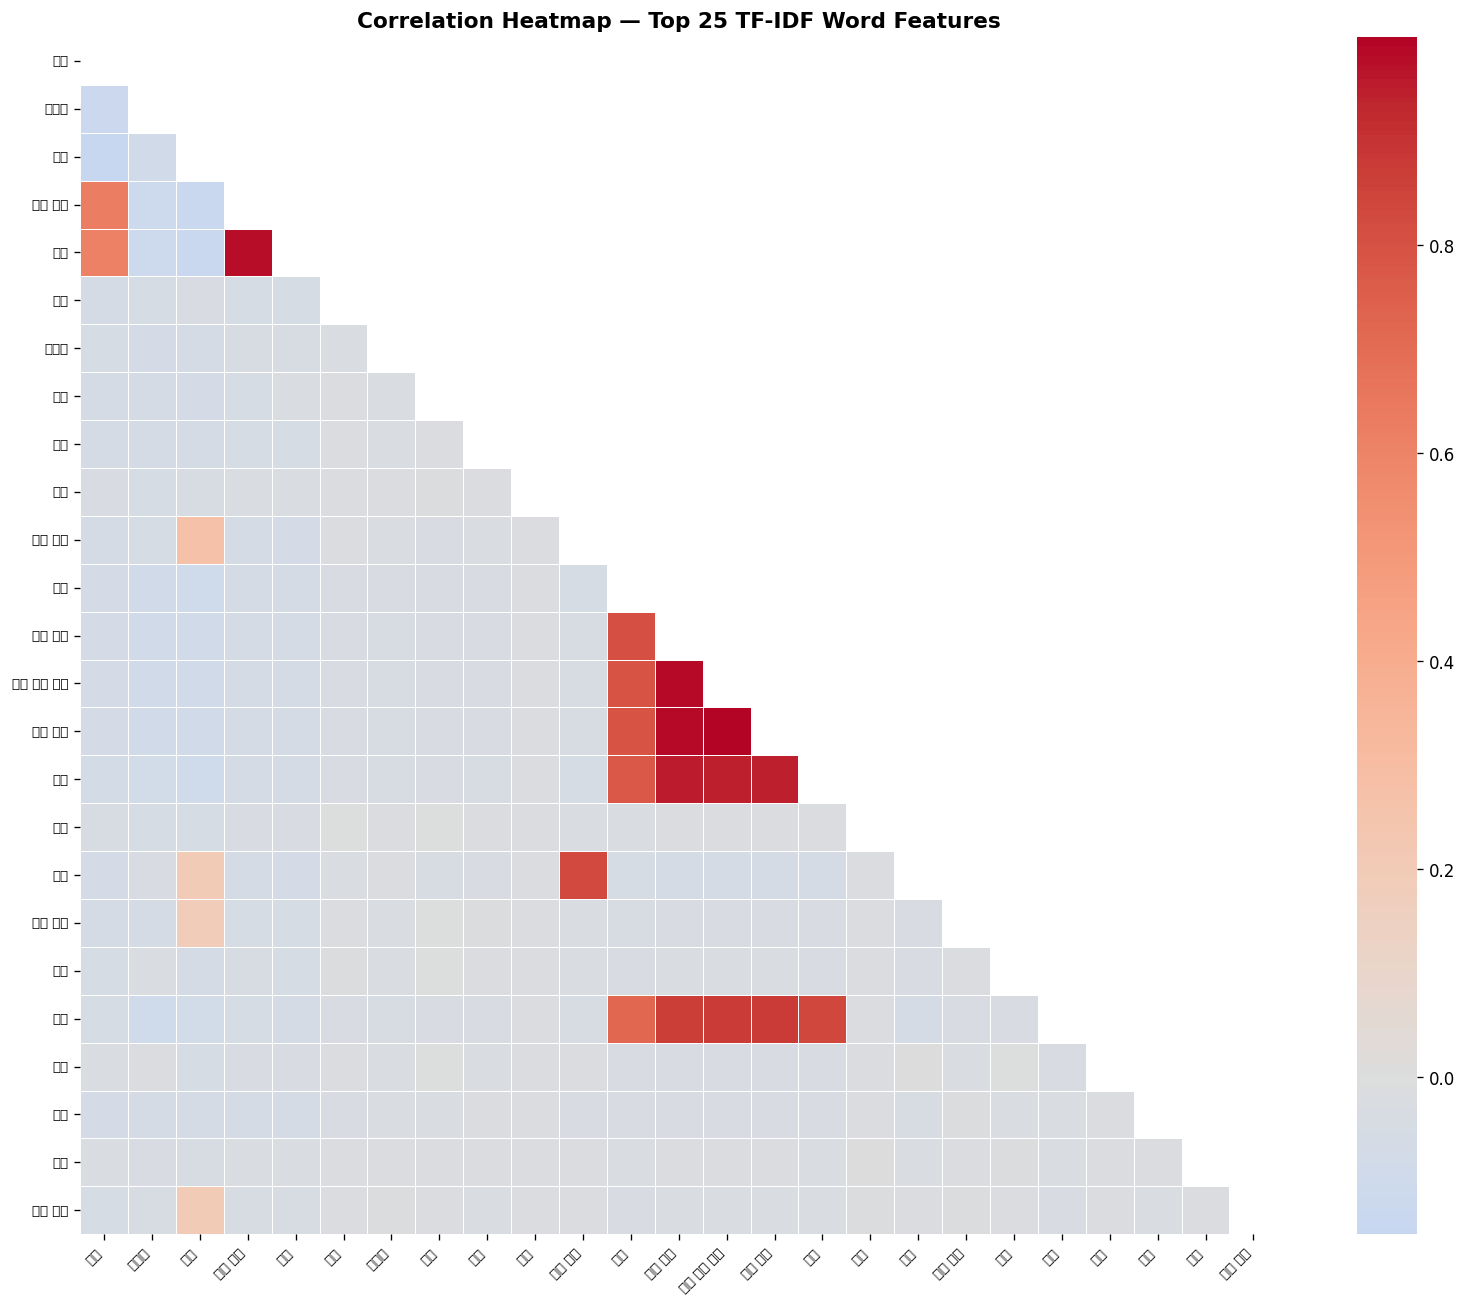

✅ Saved!


In [18]:
Xs = tfw_80.transform(X[:4000])
variances = np.asarray(Xs.power(2).mean(0) - np.power(np.asarray(Xs.mean(0)),2)).flatten()
top25 = np.argsort(variances)[-25:][::-1]
Xt25  = pd.DataFrame(Xs[:,top25].toarray(), columns=fn_w[top25])
fig, ax = plt.subplots(figsize=(14,11))
mask = np.triu(np.ones_like(Xt25.corr(), dtype=bool))
sns.heatmap(Xt25.corr(), mask=mask, cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Top 25 TF-IDF Word Features', fontsize=13, fontweight='bold')
plt.xticks(fontsize=8, rotation=45, ha='right'); plt.yticks(fontsize=8)
plt.tight_layout(); plt.savefig('results/09_correlation_heatmap.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 🗺️ Step 15: PCA Scatter Plot

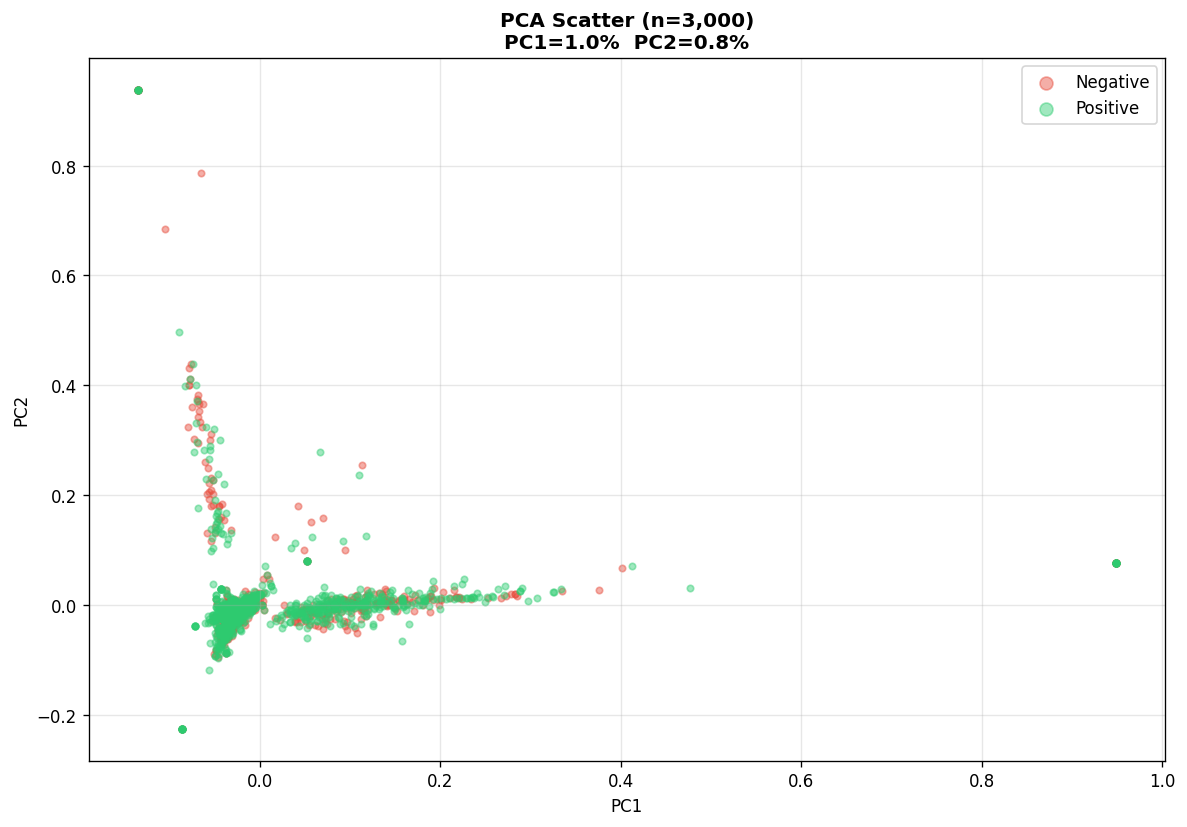

✅ Saved!


In [19]:
from sklearn.decomposition import PCA
sidx = np.random.RandomState(42).choice(len(X), 3000, replace=False)
Xsp  = tfw_80.transform(X[sidx])
ysp  = y[sidx]
pca  = PCA(n_components=2, random_state=42)
Xp   = pca.fit_transform(Xsp.toarray())
fig, ax = plt.subplots(figsize=(10,7))
for ci,cls in enumerate(['Negative','Positive']):
    m = ysp==ci
    ax.scatter(Xp[m,0], Xp[m,1], c=['#e74c3c','#2ecc71'][ci], label=cls, alpha=0.45, s=15)
ax.set_title(f'PCA Scatter (n=3,000)\nPC1={pca.explained_variance_ratio_[0]*100:.1f}%  PC2={pca.explained_variance_ratio_[1]*100:.1f}%', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(markerscale=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('results/10_pca_scatter.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 📊 Step 16: Final Summary Dashboard

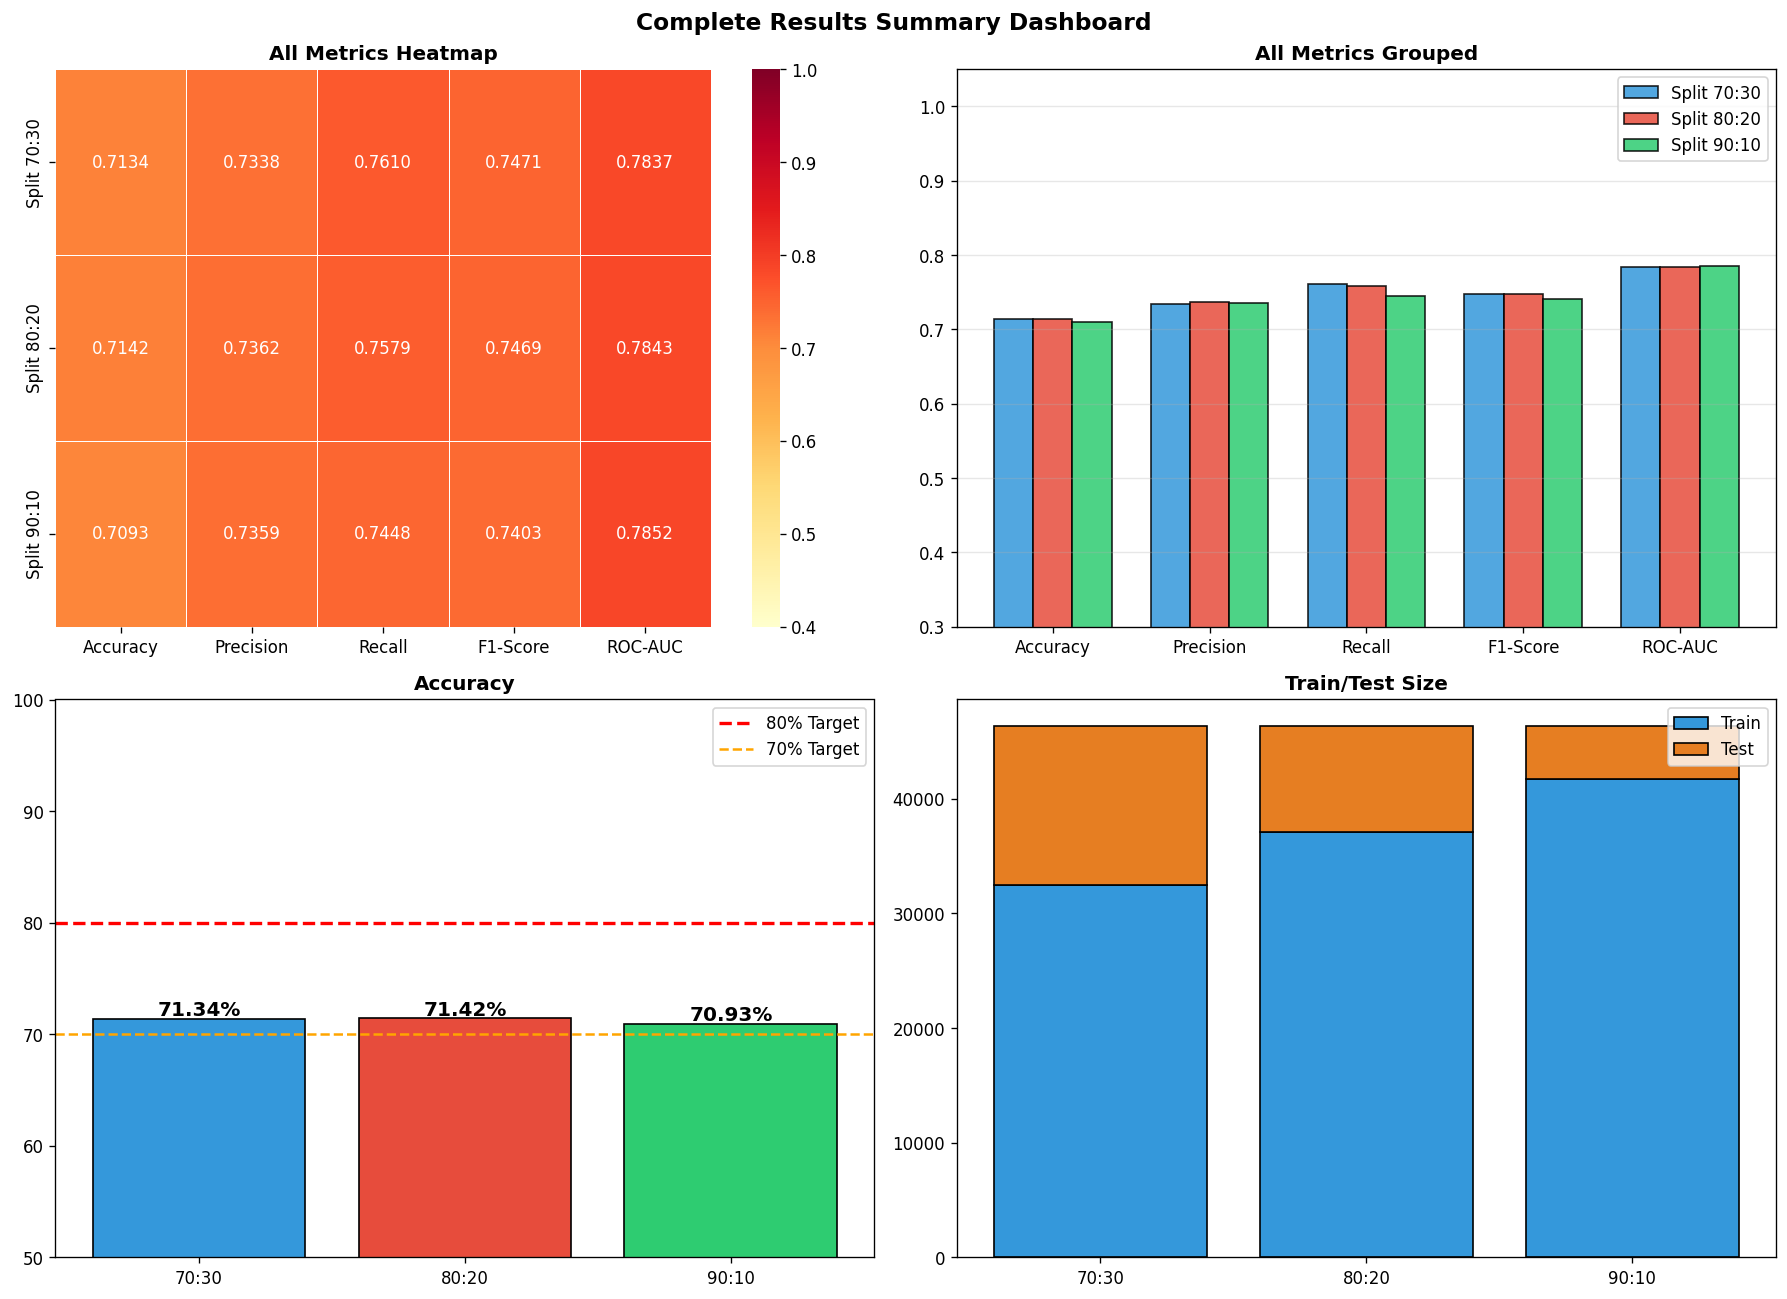

✅ Saved!


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Complete Results Summary Dashboard', fontsize=14, fontweight='bold')
all_mk=['accuracy','precision','recall','f1','roc_auc']
all_ml=['Accuracy','Precision','Recall','F1-Score','ROC-AUC']

hd  = [[all_results[s][k] for k in all_mk] for s in split_names]
hdf = pd.DataFrame(hd, index=[f'Split {s}' for s in split_names], columns=all_ml)
sns.heatmap(hdf, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[0,0], linewidths=0.5, vmin=0.4, vmax=1.0)
axes[0,0].set_title('All Metrics Heatmap', fontweight='bold')

x2=np.arange(len(all_mk))
for i,(sname,res) in enumerate(all_results.items()):
    axes[0,1].bar(x2+i*0.25,[res[k] for k in all_mk],0.25,label=f'Split {sname}',color=colors_roc[i],edgecolor='black',alpha=0.85)
axes[0,1].set_xticks(x2+0.25); axes[0,1].set_xticklabels(all_ml); axes[0,1].set_ylim([0.3,1.05])
axes[0,1].set_title('All Metrics Grouped',fontweight='bold'); axes[0,1].legend(); axes[0,1].grid(axis='y',alpha=0.3)

acc_p2=[all_results[s]['accuracy']*100 for s in split_names]
bars3=axes[1,0].bar(split_names,acc_p2,color=colors_roc,edgecolor='black')
axes[1,0].axhline(y=80,color='red',linestyle='--',lw=2,label='80% Target')
axes[1,0].axhline(y=70,color='orange',linestyle='--',lw=1.5,label='70% Target')
for bar,v in zip(bars3,acc_p2): axes[1,0].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[1,0].set_ylim([50,100]); axes[1,0].set_title('Accuracy',fontweight='bold'); axes[1,0].legend()

tr_s=[all_results[s]['train_size'] for s in split_names]
te_s=[all_results[s]['test_size_n'] for s in split_names]
axes[1,1].bar(split_names,tr_s,label='Train',color='#3498db',edgecolor='black')
axes[1,1].bar(split_names,te_s,bottom=tr_s,label='Test',color='#e67e22',edgecolor='black')
axes[1,1].set_title('Train/Test Size',fontweight='bold'); axes[1,1].legend()

plt.tight_layout(); plt.savefig('results/11_final_dashboard.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 🏆 Step 17: Final Results Summary Table

In [21]:
summary = []
for sname, res in all_results.items():
    summary.append({'Split': sname,
        'Train Size': f"{res['train_size']:,}",
        'Test Size' : f"{res['test_size_n']:,}",
        'Accuracy'  : f"{res['accuracy']*100:.2f}%",
        'Precision' : f"{res['precision']:.4f}",
        'Recall'    : f"{res['recall']:.4f}",
        'F1-Score'  : f"{res['f1']:.4f}",
        'ROC-AUC'   : f"{res['roc_auc']:.4f}",
        'PR-AUC'    : f"{res['pr_auc']:.4f}"})

sdf = pd.DataFrame(summary)
print('\n' + '='*95)
print('           📊 FINAL RESULTS — MNB BANGLA SPORTS SENTIMENT ANALYSIS')
print('='*95)
print(sdf.to_string(index=False))
print('='*95)
print(f'\n🔧 Best Hyperparameters (tuned on 80:20):')
for k,v in best_params.items(): print(f'   {k}: {v}')
print(f'   + Char TF-IDF: char_wb ngram(2,4), max_features={best_max_feat}')
print(f'   Best CV: {best_cv_score*100:.2f}%')
print(f'\n📋 Dataset: Raw={82611:,} → After cleanup={len(df_clean):,}')
print('\n⚠️  Note: Dataset এ label noise আছে (~1,751 conflicting labels)')
print('          এটাই accuracy এর সীমা নির্ধারণ করে।')
print('\n✅ সব কাজ সম্পন্ন! results/ ফোল্ডারে সব plot আছে।')
for f in sorted(os.listdir('results')): print(f'   📊 results/{f}')


           📊 FINAL RESULTS — MNB BANGLA SPORTS SENTIMENT ANALYSIS
Split Train Size Test Size Accuracy Precision Recall F1-Score ROC-AUC PR-AUC
70:30     32,427    13,898   71.34%    0.7338 0.7610   0.7471  0.7837 0.8125
80:20     37,060     9,265   71.42%    0.7362 0.7579   0.7469  0.7843 0.8125
90:10     41,692     4,633   70.93%    0.7359 0.7448   0.7403  0.7852 0.8138

🔧 Best Hyperparameters (tuned on 80:20):
   mnb__alpha: 1.0
   tfidf__max_df: 0.9
   tfidf__max_features: 30000
   tfidf__min_df: 2
   tfidf__ngram_range: (1, 3)
   + Char TF-IDF: char_wb ngram(2,4), max_features=30000
   Best CV: 64.69%

📋 Dataset: Raw=82,611 → After cleanup=46,325

⚠️  Note: Dataset এ label noise আছে (~1,751 conflicting labels)
          এটাই accuracy এর সীমা নির্ধারণ করে।

✅ সব কাজ সম্পন্ন! results/ ফোল্ডারে সব plot আছে।
   📊 results/01_dataset_overview.png
   📊 results/02_boxplot_violin.png
   📊 results/03_confusion_matrix.png
   📊 results/04_roc_curve.png
   📊 results/05_pr_curve.png
   📊 result